<a href="https://colab.research.google.com/github/kus7459-knou/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_4%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 오픈소스 기반 데이터 분석 4강 - 데이터 수집


In [ ]:
import pandas as pd

## data.csv 파일 읽기

print(df)

## 4-2 JSON 파일 읽기



In [ ]:
import json
import pandas as pd

## data.json 파일 출력

## data.json 파일 DataFrame 읽기

print(df)

## 4-3 텍스트 파일 읽기 및 데이터 추출

In [ ]:
import re

## 파일(callcenter20250301.log) 오픈 및 읽기
with open('callcenter20250301.log', 'r', encoding='utf-8') as f:
    content = f.read()
## 주민등록번호 패턴 생성

## 주민등록번호 마스킹


## 마스킹된 파일(callcenter20250301_masked.log) 오픈 및 쓰기


print("주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.")

## 4-4 Open-Meteo의 무료 날씨 API를 통한 특정 지역 온도 조회

In [ ]:
import requests
import json

url = "https://api.open-meteo.com/v1/forecast?=&=&current=temperature_2m"
params = {
    "latitude": "37.58638333",
    "longitude": "127.0203333",
    "current": "temperature_2m"
}

try:
    ## URL 및 파라미터 전송

    ## JSON 데이터 읽기

    print("API 응답:", data)
    print("서울시 종로구의 현재 온도는 : {0}{1} 입니다.".format(data['current']['temperature_2m'], data['current_units']['temperature_2m']))

except requests.exceptions.RequestException as e:
    print(f"API 호출 실패: {e}")
except json.JSONDecodeError as e:
    print(f"JSON 파싱 실패: {e}")


## 4-5 Selenium과 lxml을 이용한 웹 스크래핑

In [ ]:
!curl -o google-chrome-stable_current_amd64.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install ./google-chrome-stable_current_amd64.deb -y
!pip install selenium webdriver_manager

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from lxml import html
import time

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')               # 브라우저 창 없이 실행
chrome_options.add_argument('--no-sandbox')             # 보안모드 비활성화 (Colab 필수)
chrome_options.add_argument('--disable-dev-shm-usage')  # 메모리 부족 방지 (Colab 필수)
chrome_options.add_argument('--window-size=1920x1080')  # 창 크기 설정(가상)
chrome_options.add_argument('--disable-gpu')            # GPU 가속 비활성화 (일부 환경 안정성)
chrome_options.binary_location = "/usr/bin/google-chrome-stable"  # Colab용 크롬 경로 지정

## 드라이버 실행
driver = webdriver.Chrome(options=chrome_options)

## 사이트 접속


## 사이트 접속 대기


## 페이지 제목 출력


## 드라이버 종료
driver.quit()


# 실습 시나리오

## 공공데이터 포털 가입 및 데이터 신청

- [https://www.data.go.kr](https://www.data.go.kr)
- 한국환경공단 에어코리아 대기오염정보 데이터 신청

In [ ]:
import requests
import pandas as pd
import json
import time

# API 기본 설정
key = '46694f71666b757331396b55586b51'
base_url = "http://openapi.seoul.go.kr:8088/{}/json/energyUseDataSummaryInfo/1/1000/{}/{}".format

# 연월 리스트 생성
def get_year_months(start_year=2015, end_year=2024):
    year_months = []
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            year_months.append((year, month))
    return year_months

# API 데이터 수집 함수
def fetch_energy_data():
    records = []

    for year, month in get_year_months(2015, 2024):
        url = base_url(key, year, month)
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = response.json()

            # API 응답 구조 접근
            rows = data.get('energyUseDataSummaryInfo', {}).get('row', [])
            if not rows:
                print(f"{year}-{month:02d}: 데이터 없음")
                continue

            # 개인유형 필터링
            for row in rows:
                if row.get('MM_TYPE') == '개인':
                    records.append({
                        '연도': year,
                        '월': month,
                        '전기사용량': row.get('EUS', 0),
                        '가스사용량': row.get('GUS', 0),
                        '수도사용량': row.get('WUS', 0),
                        '지역난방사용량': row.get('HUS', 0)
                    })

            print(f"{year}-{month:02d}: 데이터 수집 완료 ({len(rows)}건)")
            time.sleep(0.3)  # 서버 요청 간격 (300ms 권장)

        except requests.exceptions.RequestException as e:
            print(f"{year}-{month:02d} API 호출 실패: {e}")
        except json.JSONDecodeError as e:
            print(f"{year}-{month:02d} JSON 파싱 실패: {e}")

    return records

# 실행
print("=== 서울시 개인 유형 에너지 사용량(2015~2024) 데이터 수집 시작 ===")
energy_data = fetch_energy_data()

# DataFrame으로 정리
df = pd.DataFrame(energy_data)
print("\n--- 수집된 데이터 미리보기 ---")
print(df.head())

# CSV 파일 저장
output_path = "seoul_energy_personal_2015_2024.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\nCSV 파일 저장 완료: {output_path}")

In [44]:
# -------------------------------
import requests
import json
import time
import pandas as pd

key = '46694f71666b757331396b55586b51'

def get_year_months(start_year=2015, end_year=2024):
    year_months = []
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            year_months.append((year, month))
    return year_months

def fetch_energy_data():
    records = []

    for year, month in get_year_months():
        url = f"http://openapi.seoul.go.kr:8088/{key}/json/energyUseDataSummaryInfo/1/100/{year}/{month:02d}"

        try:
            response = requests.get(url)
            response.raise_for_status()
            data = response.json()

            rows = data.get('energyUseDataSummaryInfo', {}).get('row', [])
            if not rows:
                print(f"{year}-{month:02d}: 데이터 없음")
                continue

            for row in rows:
                if row.get('MM_TYPE') == '개인':
                    records.append({
                        '연도': year,
                        '월': month,
                        '전기사용량': row.get('EUS', 0),
                        '가스사용량': row.get('GUS', 0),
                        '수도사용량': row.get('WUS', 0),
                        '지역난방사용량': row.get('HUS', 0)
                    })

            print(f"{year}-{month:02d}: 데이터 수집 완료")
            time.sleep(0.2)

        except requests.exceptions.RequestException as e:
            print(f"{year}-{month:02d} API 호출 실패: {e}")
        except json.JSONDecodeError as e:
            print(f"{year}-{month:02d} JSON 파싱 실패: {e}")

    return records

print("[문제1-2] 서울시 개인 유형 에너지 사용량(2015~2024) 수집")
energy_data = fetch_energy_data()
print(f"\n총 수집된 데이터 개수: {len(energy_data)}")

df = pd.DataFrame(energy_data)

output_path = "seoul_energy_personal_2015_2024.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\nCSV 파일 저장 완료: {output_path}")


print("[문제2-1] DataFrame 기본 정보 출력")
print(df.info())
print("\n--- 데이터 미리보기 (상위 5행) ---")
print(df.head())


[문제1-2] 서울시 개인 유형 에너지 사용량(2015~2024) 수집
2015-01: 데이터 수집 완료
2015-02: 데이터 수집 완료
2015-03: 데이터 수집 완료
2015-04: 데이터 수집 완료
2015-05: 데이터 수집 완료
2015-06: 데이터 수집 완료
2015-07: 데이터 수집 완료
2015-08: 데이터 수집 완료
2015-09: 데이터 수집 완료
2015-10: 데이터 수집 완료
2015-11: 데이터 수집 완료
2015-12: 데이터 수집 완료
2016-01: 데이터 수집 완료
2016-02: 데이터 수집 완료
2016-03: 데이터 수집 완료
2016-04: 데이터 수집 완료
2016-05: 데이터 수집 완료
2016-06: 데이터 수집 완료
2016-07: 데이터 수집 완료
2016-08: 데이터 수집 완료
2016-09: 데이터 수집 완료
2016-10: 데이터 수집 완료
2016-11: 데이터 수집 완료
2016-12: 데이터 수집 완료
2017-01: 데이터 수집 완료
2017-02: 데이터 수집 완료
2017-03: 데이터 수집 완료
2017-04: 데이터 수집 완료
2017-05: 데이터 수집 완료
2017-06: 데이터 수집 완료
2017-07: 데이터 수집 완료
2017-08: 데이터 수집 완료
2017-09: 데이터 수집 완료
2017-10: 데이터 수집 완료
2017-11: 데이터 수집 완료
2017-12: 데이터 수집 완료
2018-01: 데이터 수집 완료
2018-02: 데이터 수집 완료
2018-03: 데이터 수집 완료
2018-04: 데이터 수집 완료
2018-05: 데이터 수집 완료
2018-06: 데이터 수집 완료
2018-07: 데이터 수집 완료
2018-08: 데이터 수집 완료
2018-09: 데이터 수집 완료
2018-10: 데이터 수집 완료
2018-11: 데이터 수집 완료
2018-12: 데이터 수집 완료
2019-01: 데이터 수집 완료
2019-02: 데이터 수집 완료
2019-03: 데

In [8]:
import pandas as pd

# CSV 파일 불러오기
df = pd.read_csv("seoul_energy_personal_2015_2024.csv")


df["월"] = df["월"].apply(lambda x: f"{int(x):02d}")

# 계절 컬럼 생성
def get_season(month_str):
    if month_str in ["03", "04", "05"]:
        return "봄"
    if month_str in ["06", "07", "08"]:
        return "여름"
    if month_str in ["09", "10", "11"]:
        return "가을"
    if month_str in ["12", "01", "02"]:
        return "겨울"

df["계절"] = df["월"].apply(get_season)

# 결과 확인
print("\n=== 변환 결과 미리보기 ===")
print(df.head(12))

output_path = "seoul_energy_personal_2015_2024_season.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\nCSV 파일 저장 완료: {output_path}")


=== 변환 결과 미리보기 ===
      연도   월      전기사용량       가스사용량         수도사용량       지역난방사용량  계절
0   2015  01  193784708  59133720.0  1.281976e+07  2.274084e+07  겨울
1   2015  02  189974230  56487358.0  1.265689e+07  1.879332e+07  겨울
2   2015  03  175215719  49984873.0  1.265547e+07  1.382635e+07   봄
3   2015  04  183891769  37306841.0  1.295477e+07  5.836003e+06   봄
4   2015  05  177289769  22060892.0  1.308673e+07  1.320896e+06   봄
5   2015  06  186073153  12677645.0  1.424165e+07  2.943126e+05  여름
6   2015  07  165114568   8893640.0  1.208388e+07  7.028636e+05  여름
7   2015  08  242000479   7619018.0  1.516455e+07  4.602890e+05  여름
8   2015  09  207540868   6518422.0  1.441908e+07  3.057107e+05  가을
9   2015  10  186473958   8924018.0  1.471183e+07  3.167520e+06  가을
10  2015  11  196892030  20322557.0  1.369267e+07  1.121098e+07  가을
11  2015  12  203388142  40095231.0  1.390416e+07  2.110262e+07  겨울

CSV 파일 저장 완료: seoul_energy_personal_2015_2024_season.csv



=== 연도별 총 에너지 사용량 ===
     연도          총사용량
0  2015  2.899817e+09
1  2016  3.259907e+09
2  2017  3.409270e+09
3  2018  3.682193e+09
4  2019  3.790736e+09
5  2020  3.559380e+09
6  2021  4.105176e+09
7  2022  4.132556e+09
8  2023  4.120742e+09
9  2024  4.132734e+09


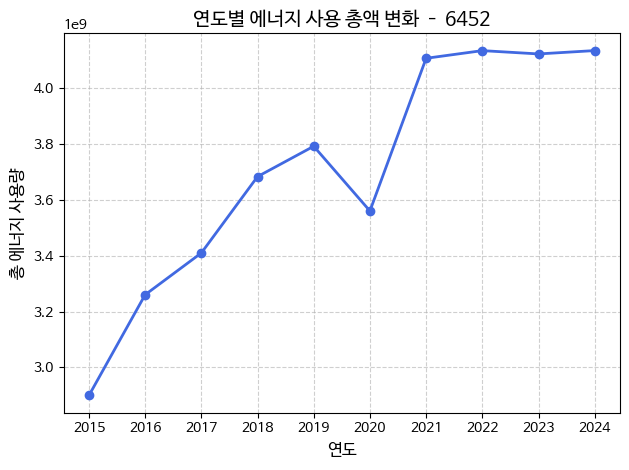


그래프 저장 완료: 연도별 에너지 사용 총액 변화 – 6452.png


In [12]:
# -------------------------------
# [문제3] 연도별 에너지 사용 총합 변화량 시각화
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')
# 1️⃣ CSV 파일 불러오기
df = pd.read_csv("seoul_energy_personal_2015_2024.csv")

# 2️⃣ 연도별 총 에너지 사용량 계산 (전기 + 가스 + 수도 + 지역난방)
df["총사용량"] = df["전기사용량"] + df["가스사용량"] + df["수도사용량"] + df["지역난방사용량"]

# 3️⃣ 연도별 총합 집계
yearly_total = df.groupby("연도")["총사용량"].sum().reset_index()

print("\n=== 연도별 총 에너지 사용량 ===")
print(yearly_total)

# 4️⃣ 선 그래프 시각화
plt.figure(figsize=(10,6))
plt.plot(
    yearly_total["연도"],
    yearly_total["총사용량"],
    marker='o',
    linestyle='-',
    color='royalblue',
    linewidth=2
)

# 5️⃣ 그래프 꾸미기
plt.title("연도별 에너지 사용 총액 변화 – 6452", fontsize=14)
plt.xlabel("연도", fontsize=12)
plt.ylabel("총 에너지 사용량", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(yearly_total["연도"])  # 연도별 눈금 표시
plt.tight_layout()

# 6️⃣ 그래프 저장
plt.savefig("연도별 에너지 사용 총액 변화 – 6452.png", dpi=300)
plt.show()

print("\n그래프 저장 완료: 연도별 에너지 사용 총액 변화 – 6452.png")



=== 계절별 가스 사용량 평균 ===
   계절         가스사용량
0  가을  1.501570e+07
1  겨울  6.657663e+07
2   봄  4.443600e+07
3  여름  1.131019e+07


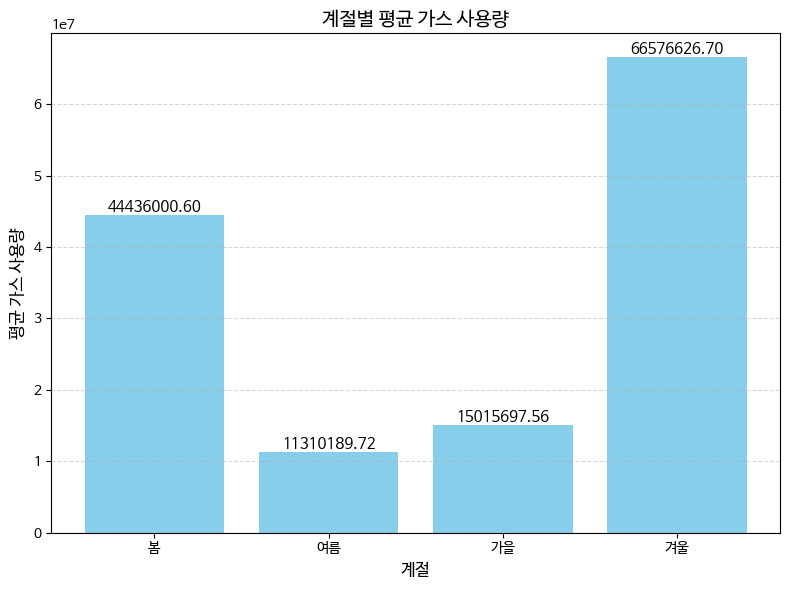


그래프 저장 완료: seasonal_gas_usage_avg.png


In [17]:
# -------------------------------
# [문제4] 계절별 가스 사용량 평균 시각화
# -------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ 데이터 불러오기
df = pd.read_csv("seoul_energy_personal_2015_2024_season.csv")

# 2️⃣ 계절별 가스 사용량 평균 계산
season_avg = df.groupby("계절")["가스사용량"].mean().reset_index()

print("\n=== 계절별 가스 사용량 평균 ===")
print(season_avg)

# 계절 순서 정렬 (봄 → 여름 → 가을 → 겨울 순)
order = ["봄", "여름", "가을", "겨울"]
season_avg["계절"] = pd.Categorical(season_avg["계절"], categories=order, ordered=True)
season_avg = season_avg.sort_values("계절")

# 3️⃣ 막대 그래프 시각화
plt.figure(figsize=(8,6))
bars = plt.bar(season_avg["계절"], season_avg["가스사용량"], color="skyblue")

plt.title("계절별 평균 가스 사용량", fontsize=14)
plt.xlabel("계절", fontsize=12)
plt.ylabel("평균 가스 사용량", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# 4️⃣ 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",   # 소수 둘째 자리까지 표시
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.savefig("seasonal_gas_usage_avg.png", dpi=300)
plt.show()

print("\n그래프 저장 완료: seasonal_gas_usage_avg.png")
